In [45]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
# Load data
df = pd.read_excel('spam.xlsk')
# Cleaning
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],
inplace=True)
df.rename(columns={'v1':'target','v2':'text'}, inplace=True)
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df = df.drop_duplicates(keep='first')
# CRITICAL FIX: Convert text to string to avoid TypeError
df['text'] = df['text'].astype(str).fillna('')

In [46]:
import nltk
nltk.download('punkt')
# 1. num_characters
df['num_characters'] = df['text'].apply(len)
# 2. num_words
df['num_words'] = df['text'].apply(lambda x:
len(nltk.word_tokenize(x)))
# 3. num_sentences (Fixed Line)
df['num_sentences'] = df['text'].apply(lambda x:
len(nltk.sent_tokenize(x)))
# Now describe will work perfectly
print(df[['num_characters','num_words','num_sentences']].describe())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


       num_characters    num_words  num_sentences
count     5169.000000  5169.000000    5169.000000
mean        78.980267    18.455794       1.965564
std         58.239404    13.324758       1.448541
min          2.000000     1.000000       1.000000
25%         36.000000     9.000000       1.000000
50%         60.000000    15.000000       1.000000
75%        117.000000    26.000000       2.000000
max        910.000000   220.000000      38.000000


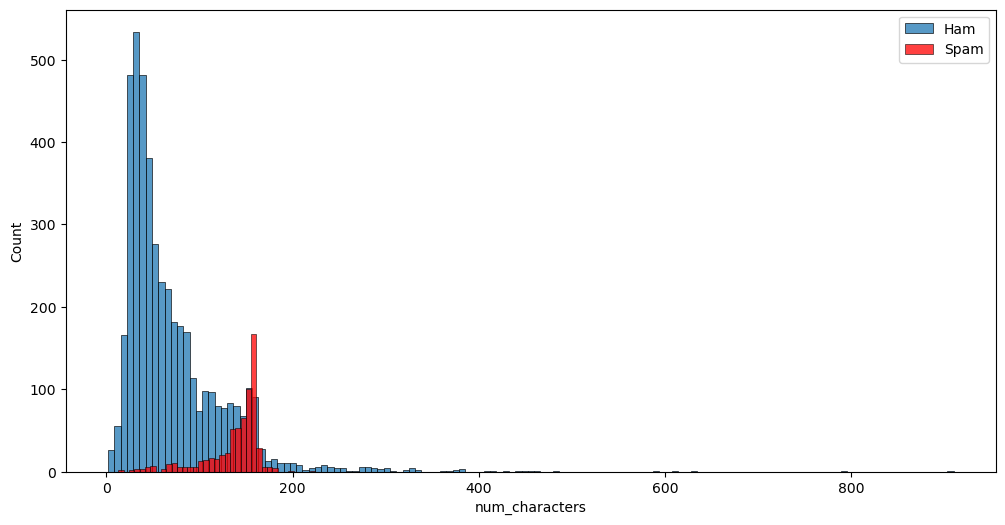

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'], label='Ham')
sns.histplot(df[df['target'] == 1]['num_characters'], color='red',
label='Spam')
plt.legend()
plt.show()

In [48]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
import nltk
nltk.download('stopwords')
nltk.download('punkt')

# Is function ko dhyan se dekhein, har line ke aage space hai
def transform_text(text):
    text = text.lower() # Yahan 4 spaces ka gap hona chahiye
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(ps.stem(i))
            
    return " ".join(y)

# Apply karne ke liye ye line run karein
df['transformed_text'] = df['text'].apply(transform_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=2)
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Accuracy: 0.971953578336557
Precision: 1.0
